# Real-Time Hand Gesture Classification with MobileNet and OpenCV

This project builds an end-to-end computer vision pipeline for classifying rock-paper-scissors hand gestures from images and webcam input. It compares a custom convolutional neural network baseline against a MobileNet transfer learning model, then extends the best-performing approach toward real-time webcam inference using OpenCV.

The project was originally developed from a university computer vision assignment and later refactored into a standalone portfolio project focused on dataset preparation, model comparison, evaluation, and practical deployment.

## Project Goals

The main goals of this project are to:

- Prepare a balanced image dataset for rock-paper-scissors gesture classification.
- Build a custom CNN baseline using PyTorch.
- Apply transfer learning using MobileNet pretrained on ImageNet.
- Compare model performance using accuracy, confusion matrices, and error analysis.
- Explore real-time webcam inference using OpenCV.
- Present the project as a clean, reproducible AI/ML portfolio project.

## Project Workflow

The notebook follows this workflow:

1. Environment setup and configuration
2. Dataset setup and image discovery
3. Stratified train/dev/test split
4. Exploratory data analysis
5. PyTorch dataset and dataloader creation
6. Custom CNN baseline training
7. MobileNet transfer learning
8. Training curve visualization
9. Model evaluation and comparison
10. Error analysis and failure case inspection
11. Real-time webcam inference planning
12. Conclusion and future improvements

## Project Scope

This version focuses on static image classification and real-time frame-by-frame webcam inference. The model predicts one of three gesture classes: rock, paper, or scissors.

This project does not yet perform dynamic gesture recognition, hand tracking, or temporal video classification. These are listed as future improvements.

# 1. Environment Setup and Configuration

## 1.1 Imports and Reproducibility

This section imports the main libraries used throughout the project and sets a fixed random seed. Reproducibility is important in machine learning because dataset splits, model initialization, and training behavior can change between runs if randomness is not controlled.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## 1.2 Random Seed

A fixed seed is used to make random operations more consistent across runs. This helps keep dataset splitting and model experiments easier to compare.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## 1.3 Device Configuration

The notebook automatically selects the best available device:

- CUDA, if running on an NVIDIA GPU
- MPS, if running on Apple Silicon
- CPU, if no accelerator is available

This makes the notebook portable across different machines.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 1.4 Project Paths

The project uses a consistent folder structure so that data, outputs, and models are easy to manage. The notebook is stored inside the `notebooks/` folder, so paths are defined relative to the project root.

In [4]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "archive"
SPLITS_DIR = DATA_DIR / "splits"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for directory in [DATA_DIR, SPLITS_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {RAW_DATA_DIR}")
print(f"Splits directory: {SPLITS_DIR}")
print(f"Outputs directory: {OUTPUTS_DIR}")
print(f"Models directory: {MODELS_DIR}")

Project root: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification
Raw data directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/archive
Splits directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits
Outputs directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs
Models directory: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/models


## 1.5 Class Labels

The classification task contains three hand gesture classes: rock, paper, and scissors. These labels are mapped to numeric IDs for model training.

In [5]:
CLASS_NAMES = ["rock", "paper", "scissors"]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_IDX.items()}

print(CLASS_TO_IDX)

{'rock': 0, 'paper': 1, 'scissors': 2}


# 2. Dataset Setup and Image Discovery

The original dataset is expected to be stored inside `data/archive/`, with one folder per class. This section scans the dataset directory, validates the class folders, and creates a dataframe containing each image path and its corresponding label.

## 2.1 Validate Dataset Directory

Before processing images, the notebook checks whether the expected dataset directory and class folders exist. This helps catch path issues early.

In [6]:
if not RAW_DATA_DIR.exists():
    raise FileNotFoundError(
        f"Raw dataset directory not found: {RAW_DATA_DIR}\n"
        "Please place the dataset inside data/archive/ with class folders: rock, paper, scissors."
    )

missing_classes = [class_name for class_name in CLASS_NAMES if not (RAW_DATA_DIR / class_name).exists()]

if missing_classes:
    raise FileNotFoundError(f"Missing class folders: {missing_classes}")

print("Dataset directory found.")
print("Class folders found:", CLASS_NAMES)

Dataset directory found.
Class folders found: ['rock', 'paper', 'scissors']


## 2.2 Discover Image Files

The dataset is scanned for image files from each class folder. The result is stored in a dataframe with two columns:

- `path`: path to the image file
- `label`: class label of the image

In [7]:
image_extensions = {".jpg", ".jpeg", ".png"}

records = []

for class_name in CLASS_NAMES:
    class_dir = RAW_DATA_DIR / class_name
    
    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in image_extensions:
            records.append({
                "path": str(image_path.relative_to(PROJECT_ROOT)),
                "label": class_name
            })

images_df = pd.DataFrame(records)

print(f"Total images found: {len(images_df)}")
images_df.head()

Total images found: 2717


,path,label
0,data/archive/rock/rock_213.png,rock
1,data/archive/rock/rock_575.png,rock
2,data/archive/rock/rock_561.png,rock
3,data/archive/rock/rock_207.png,rock
4,data/archive/rock/rock_549.png,rock


## 2.3 Check Class Distribution

A quick class count is used to confirm how many images were discovered for each gesture class.

In [8]:
class_counts = images_df["label"].value_counts().reindex(CLASS_NAMES)

class_counts

label
rock        907
paper       907
scissors    903
Name: count, dtype: int64

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2.4 Dataset Discovery Summary

The image discovery step creates a clean dataframe that will be used for stratified train/dev/test splitting. Each image is represented by its relative path and class label, which makes the dataset easier to manage across different machines.

# 3. Stratified Train/Dev/Test Split

The dataset is split into training, development, and test sets using a 60/20/20 ratio. Stratified splitting is used so that each split keeps approximately the same proportion of rock, paper, and scissors images.

This helps ensure that evaluation results are not biased by class imbalance.

## 3.1 Create Stratified Splits

The full image dataframe is first split into training and temporary data. The temporary data is then split equally into development and test sets. Both operations use stratification based on the class label.

In [9]:
train_df, temp_df = train_test_split(
    images_df,
    test_size=0.40,
    stratify=images_df["label"],
    random_state=SEED,
    shuffle=True
)

devtest_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
    shuffle=True
)

print(f"Training samples: {len(train_df)}")
print(f"Devtest samples: {len(devtest_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 1630
Devtest samples: 543
Test samples: 544


## 3.2 Save Split CSV Files

The generated splits are saved as CSV files so they can be reused consistently across experiments.

In [10]:
train_csv_path = SPLITS_DIR / "train.csv"
devtest_csv_path = SPLITS_DIR / "devtest.csv"
test_csv_path = SPLITS_DIR / "test.csv"

train_df.to_csv(train_csv_path, index=False)
devtest_df.to_csv(devtest_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"Saved: {train_csv_path}")
print(f"Saved: {devtest_csv_path}")
print(f"Saved: {test_csv_path}")

Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/train.csv
Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/devtest.csv
Saved: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/data/splits/test.csv


## 3.3 Verify Split Distribution

The class distribution of each split is checked to confirm that stratified splitting preserved class balance.

In [11]:
split_distribution = pd.DataFrame({
    "train": train_df["label"].value_counts().reindex(CLASS_NAMES),
    "devtest": devtest_df["label"].value_counts().reindex(CLASS_NAMES),
    "test": test_df["label"].value_counts().reindex(CLASS_NAMES)
})

split_distribution

,train,devtest,test
label,,,
rock,544,181,182
paper,544,181,182
scissors,542,181,180


<Figure size 800x500 with 0 Axes>

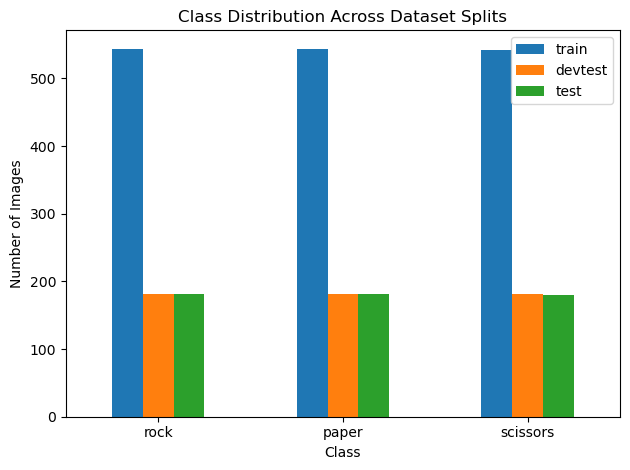

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/split_class_distribution.png


In [12]:
plt.figure(figsize=(8, 5))
split_distribution.plot(kind="bar")
plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()

split_distribution_path = FIGURES_DIR / "split_class_distribution.png"
plt.savefig(split_distribution_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {split_distribution_path}")

## 3.4 Split Summary

The generated train, devtest, and test sets maintain similar class proportions across all three gesture classes. This creates a fair experimental setup for comparing the custom CNN baseline and MobileNet transfer learning model.

# 4. Exploratory Data Analysis

This section explores the prepared dataset splits visually. The goal is to confirm that the dataset contains sensible examples from each class and that the image files can be loaded correctly before model training.

## 4.1 Load Saved Dataset Splits

The saved CSV files are loaded back into dataframes. This makes the notebook reproducible because later sections use the same split files instead of creating new random splits.

In [13]:
train_df = pd.read_csv(SPLITS_DIR / "train.csv")
devtest_df = pd.read_csv(SPLITS_DIR / "devtest.csv")
test_df = pd.read_csv(SPLITS_DIR / "test.csv")

print(f"Train set: {len(train_df)} images")
print(f"Devtest set: {len(devtest_df)} images")
print(f"Test set: {len(test_df)} images")

Train set: 1630 images
Devtest set: 543 images
Test set: 544 images


## 4.2 Display Sample Images by Split

A small grid of sample images is displayed to inspect examples from each class across the training, development, and test sets.

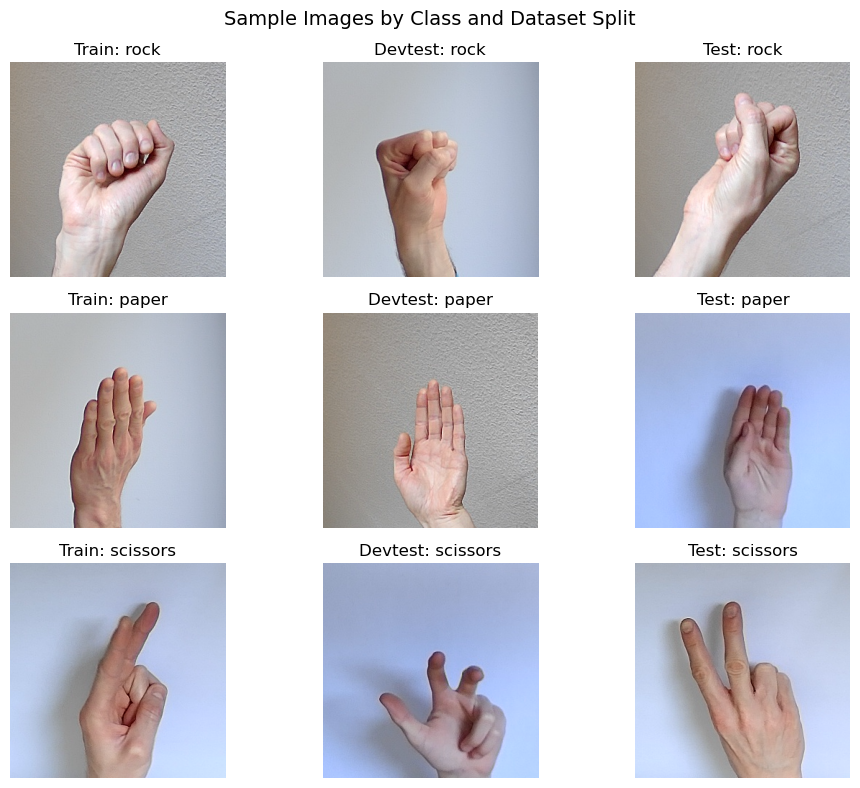

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/sample_images_by_split.png


In [14]:
def get_sample_image(df, class_name):
    sample_row = df[df["label"] == class_name].sample(1, random_state=SEED).iloc[0]
    image_path = PROJECT_ROOT / sample_row["path"]
    return Image.open(image_path).convert("RGB"), sample_row["label"]


splits = {
    "Train": train_df,
    "Devtest": devtest_df,
    "Test": test_df
}

fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=len(splits),
    figsize=(10, 8)
)

for row_idx, class_name in enumerate(CLASS_NAMES):
    for col_idx, (split_name, split_df) in enumerate(splits.items()):
        image, label = get_sample_image(split_df, class_name)
        ax = axes[row_idx, col_idx]
        ax.imshow(image)
        ax.set_title(f"{split_name}: {label}")
        ax.axis("off")

plt.suptitle("Sample Images by Class and Dataset Split", fontsize=14)
plt.tight_layout()

sample_grid_path = FIGURES_DIR / "sample_images_by_split.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {sample_grid_path}")

## 4.3 Inspect Image Sizes

Image size consistency is important because deep learning models require fixed input dimensions. This check helps identify whether resizing transforms will be required in the PyTorch pipeline.

In [15]:
image_sizes = []

for _, row in images_df.iterrows():
    image_path = PROJECT_ROOT / row["path"]
    with Image.open(image_path) as img:
        image_sizes.append({
            "width": img.width,
            "height": img.height,
            "label": row["label"]
        })

image_sizes_df = pd.DataFrame(image_sizes)
image_sizes_df.head()

,width,height,label
0,300,300,rock
1,300,300,rock
2,300,300,rock
3,300,300,rock
4,300,300,rock


In [16]:
image_sizes_df[["width", "height"]].describe()

,width,height
count,2717.0,2717.0
mean,300.0,300.0
std,0.0,0.0
min,300.0,300.0
25%,300.0,300.0
50%,300.0,300.0
75%,300.0,300.0
max,300.0,300.0


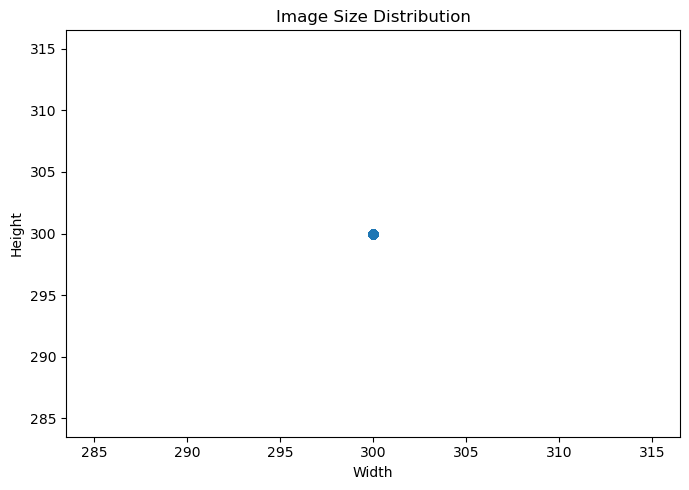

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/image_size_distribution.png


In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(image_sizes_df["width"], image_sizes_df["height"], alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()

image_size_path = FIGURES_DIR / "image_size_distribution.png"
plt.savefig(image_size_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {image_size_path}")

## 4.4 EDA Summary

The exploratory analysis confirmed that all three gesture classes are represented consistently across the dataset splits. Visual inspection showed that the images are correctly labelled and follow a similar visual style, which is useful for supervised image classification.

The image dimension analysis also revealed that all images in the dataset already have a uniform size of 300×300 pixels. This simplifies preprocessing because no additional aspect-ratio correction or image normalization strategy is required before resizing for model training.

Overall, the dataset appears clean, balanced, and suitable for both the custom CNN baseline and MobileNet transfer learning experiments.

# 5. PyTorch Dataset and DataLoader Pipeline

This section converts the CSV-based dataset splits into PyTorch datasets and dataloaders. A custom dataset class is used to load images from file paths, apply preprocessing transforms, and convert text labels into numeric class IDs.

A clean data pipeline is important because it makes model training, validation, and testing consistent across experiments.

## 5.1 Image Preprocessing Transforms

The images in the dataset are already 300×300 pixels, but they are resized to 224×224 to align with common ImageNet-based model input sizes such as MobileNet.

The transform pipeline also converts images into tensors and normalizes pixel values using ImageNet mean and standard deviation values. This is especially important for transfer learning because MobileNet was originally trained using ImageNet-style normalization.

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: 224x224
Batch size: 32


## 5.2 Custom PyTorch Dataset

The custom dataset reads image paths and labels from a dataframe. Each image is loaded using PIL, converted to RGB, transformed into a tensor, and paired with its encoded numeric label.

In [19]:
class GestureDataset(Dataset):
    def __init__(self, dataframe, project_root, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.project_root = Path(project_root)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = self.project_root / row["path"]
        image = Image.open(image_path).convert("RGB")
        
        label_name = row["label"]
        label = self.class_to_idx[label_name]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## 5.3 Create Dataset Objects

The training set uses the training transform, while the development and test sets use the evaluation transform. At this stage, both transforms are intentionally simple so that the baseline experiments remain easy to interpret.

In [20]:
train_dataset = GestureDataset(
    dataframe=train_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=train_transform
)

devtest_dataset = GestureDataset(
    dataframe=devtest_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

test_dataset = GestureDataset(
    dataframe=test_df,
    project_root=PROJECT_ROOT,
    class_to_idx=CLASS_TO_IDX,
    transform=eval_transform
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Devtest dataset size: {len(devtest_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 1630
Devtest dataset size: 543
Test dataset size: 544


## 5.4 Create DataLoaders

DataLoaders handle batching, shuffling, and efficient loading during training and evaluation. The training dataloader is shuffled so the model does not learn from images in a fixed order. The development and test dataloaders are not shuffled because they are used for evaluation.

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

devtest_loader = DataLoader(
    devtest_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_images, batch_labels = next(iter(train_loader))

print(f"Image batch shape: {batch_images.shape}")
print(f"Label batch shape: {batch_labels.shape}")
print(f"Example labels: {batch_labels[:10].tolist()}")

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Example labels: [2, 1, 0, 2, 0, 1, 2, 2, 2, 1]


## 5.5 Visual Batch Inspection

Before training, a batch of images is visualized after reversing the normalization. This confirms that the dataloader is returning images and labels correctly.

In [22]:
def denormalize_image(tensor_image, mean, std):
    image = tensor_image.clone().detach().cpu()
    
    for channel, mean_value, std_value in zip(image, mean, std):
        channel.mul_(std_value).add_(mean_value)
    
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0).numpy()
    
    return image

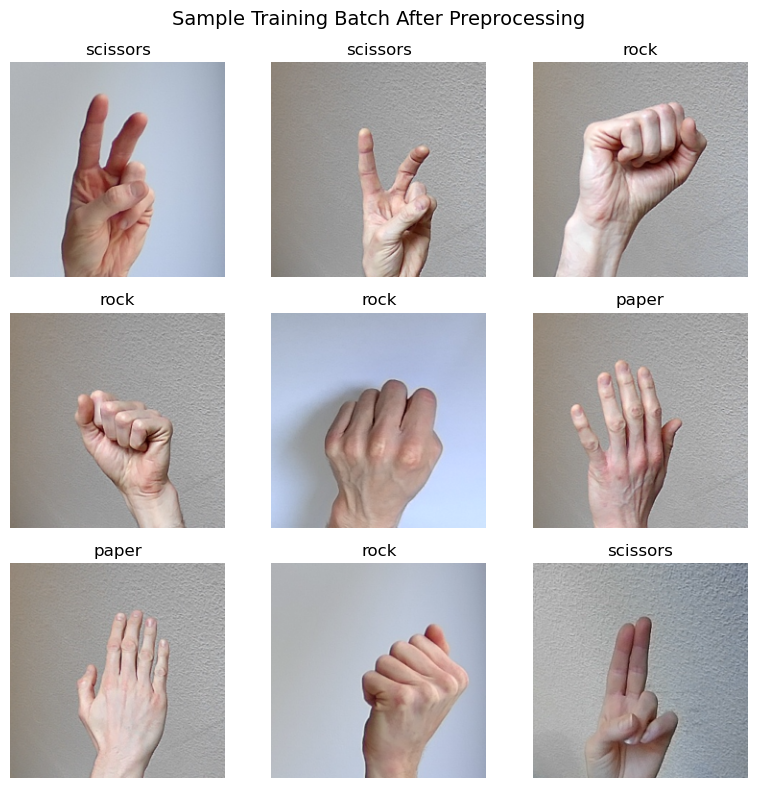

Saved figure to: /Users/razinrayanrahat/Documents/python_projects/real-time-gesture-classification/outputs/figures/preprocessed_training_batch.png


In [23]:
images, labels = next(iter(train_loader))

num_images = 9
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for idx, ax in enumerate(axes.flat):
    image = denormalize_image(images[idx], imagenet_mean, imagenet_std)
    label = IDX_TO_CLASS[labels[idx].item()]
    
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("Sample Training Batch After Preprocessing", fontsize=14)
plt.tight_layout()

batch_preview_path = FIGURES_DIR / "preprocessed_training_batch.png"
plt.savefig(batch_preview_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {batch_preview_path}")

## 5.6 Data Pipeline Summary

The PyTorch data pipeline successfully converts image paths and labels from CSV files into batched tensors ready for model training. Images are resized to 224×224, normalized using ImageNet statistics, and loaded through separate dataloaders for training, development, and testing.

This shared data pipeline will be used for both the custom CNN baseline and the MobileNet transfer learning model, making the comparison between the two approaches more consistent.